# S04.10 — Clustering jerárquico
## Módulo 3, Tema 1: Introducción a Machine Learning — Subtema 4

**Técnica:** clustering jerárquico aglomerativo (Ward) — `scipy.cluster.hierarchy`, `sklearn.cluster.AgglomerativeClustering`
**Tarea:** aprendizaje **no supervisado** — estructura anidada de segmentos
**Dataset:** Sintético v2 — 30,000 pólizas; submuestra determinística de 500 (memoria O(n²))

---

## 1. Contexto actuarial

El clustering **jerárquico aglomerativo** empieza con cada póliza como su propio grupo y **fusiona**
iterativamente los dos grupos más cercanos hasta llegar a un único grupo, produciendo un **árbol**
(dendrograma). No requiere fijar el número de clusters antes de ajustar: se decide **cortando** el
dendrograma. Revela **estructura anidada** (clusters dentro de clusters), útil para analizar la
cartera a distintos niveles de granularidad.

Regla de datos: el ajuste usa solo `CLUSTERING_FEATURES`; se excluyen `id_poliza_sin` y todos los
targets.

> *Fuentes principales:* ESL Cap. 14 §14.3.12; ISLP Cap. 12 §12.4.2; scikit-learn + scipy.cluster.hierarchy.

## 2. Fundamento matemático

### 2.1 Linkage

El **linkage** define cómo se mide la "cercanía" entre dos clusters:
- **Single:** distancia mínima entre puntos (tiende a encadenar).
- **Complete:** distancia máxima (grupos compactos).
- **Average:** distancia media.
- **Ward:** minimiza el aumento de varianza intra-cluster al fusionar (usado aquí).

### 2.2 Método de Ward

Ward fusiona el par $(A,B)$ que produce el menor aumento de la suma de cuadrados intra-cluster. El
incremento al fusionar es:

$$\Delta(A,B)=\frac{|A|\,|B|}{|A|+|B|}\,\|\mathbf{c}_A-\mathbf{c}_B\|^2$$

donde $\mathbf{c}_A,\mathbf{c}_B$ son los centroides y $|A|,|B|$ los tamaños. **Supuestos/sesgos:**
favorece grupos compactos y de tamaño similar (como K-Means), usa distancia euclidiana (requiere
escalamiento) y es sensible a outliers.

In [1]:
import sys
from pathlib import Path

_candidates = [Path.cwd() / "", Path.cwd().parent / "", Path.cwd().parent.parent / ""]
_src_path = next((p for p in _candidates if (p / "simulate_portfolio_v2.py").exists()), None)
if _src_path is None:
    raise FileNotFoundError(
        "No se encontró simulate_portfolio_v2.py. "
        "Ejecutar desde la raíz del proyecto o desde content/notebooks/."
    )
sys.path.insert(0, str(_src_path))

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from simulate_portfolio_v2 import (
    simulate_auto_insurance_portfolio_v2,
    FEATURE_COLUMNS, TARGET_COLUMNS, CLUSTERING_FEATURES,
)

SEED = 20260618
N    = 30_000
NAVY = "#003B5C"; GOLD = "#C8A33A"; RED = "#C0392B"; GREEN = "#2E7D44"
CLUSTER_COLORS = ["#003B5C", "#C8A33A", "#2E7D44", "#C0392B", "#6A5ACD", "#008B8B", "#B8860B"]

plt.rcParams.update({"figure.dpi": 100, "font.size": 11})
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

df = simulate_auto_insurance_portfolio_v2(n_policies=N, seed=SEED)
print(f"Dataset cargado: {df.shape[0]:,} filas x {df.shape[1]} columnas")

# ── Regla de seguridad: el clustering NUNCA usa targets ni identificadores ────
assert set(CLUSTERING_FEATURES).isdisjoint(set(TARGET_COLUMNS)), \
    "CLUSTERING_FEATURES no debe intersecar TARGET_COLUMNS"
assert "id_poliza_sin" not in CLUSTERING_FEATURES, "id_poliza_sin no es feature de clustering"
assert set(CLUSTERING_FEATURES).issubset(set(FEATURE_COLUMNS)), \
    "CLUSTERING_FEATURES debe ser subconjunto de FEATURE_COLUMNS"
print("Variables de clustering (canonicas):", CLUSTERING_FEATURES)
print("Excluidas del ajuste: id_poliza_sin y todos los targets:", TARGET_COLUMNS)
print("Verificacion CLUSTERING_FEATURES ∩ TARGET_COLUMNS = vacio: OK")


Dataset cargado: 30,000 filas x 23 columnas
Variables de clustering (canonicas): ['edad', 'suma_asegurada', 'num_renovaciones', 'antiguedad_vehiculo', 'kilometraje']
Excluidas del ajuste: id_poliza_sin y todos los targets: ['prima_neta', 'n_siniestros', 'monto_siniestro', 'siniestro_alto', 'status_poliza']
Verificacion CLUSTERING_FEATURES ∩ TARGET_COLUMNS = vacio: OK


## 3. Preparación: submuestra de 500 y escalamiento

La matriz de distancias es **O(n²)** en memoria y tiempo. Con n=30,000:
- la **matriz completa** de distancias `float64` ocuparía 30,000² × 8 bytes ≈ **6.7 GiB**;
- el **vector condensado** (solo el triángulo superior, `n(n−1)/2` distancias) ≈ **3.35 GiB**
  (antes de overhead de Python/SciPy).

Ambas cifras hacen el cálculo **costoso y poco prudente para este material reproducible**. Usamos
una **submuestra determinística de 500** pólizas (`sample`, `random_state=SEED`): produce un
dendrograma legible en fracciones de segundo.

In [3]:
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

HIER_SUB = 500 # si es mas grande el costo computacional es mas alto
HIER_K = 3

sub_h = df.sample(n=HIER_SUB, random_state=SEED)
X_h = StandardScaler().fit_transform(sub_h[CLUSTERING_FEATURES].to_numpy(dtype=float))
Z = linkage(X_h, method="ward")
print(f"Submuestra jerarquica: {X_h.shape[0]} obs. (determinista)")
print(f"Matriz de linkage Z: {Z.shape[0]} fusiones")


Submuestra jerarquica: 500 obs. (determinista)
Matriz de linkage Z: 499 fusiones


## 4. Dendrograma y corte razonado

Cortamos el dendrograma para obtener K = 4 grupos, a una altura entre las dos fusiones superiores.

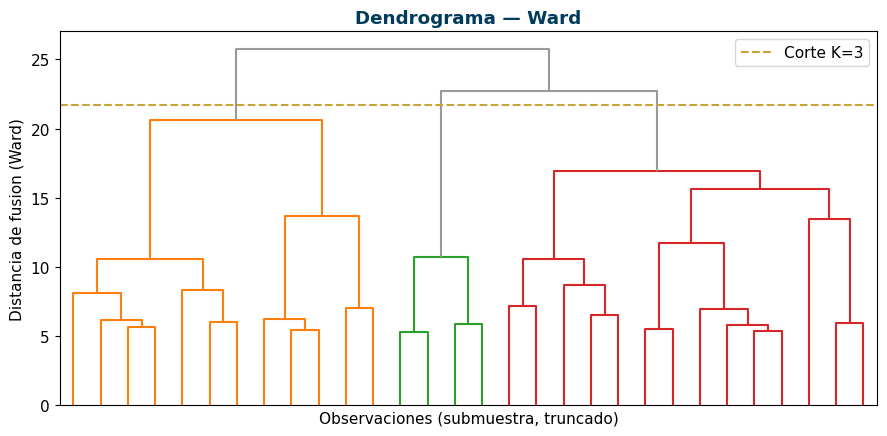

Corte K=3 a altura ≈ 21.68
Tamanos de grupo: [np.int64(240), np.int64(20), np.int64(240)]


In [4]:
merge_heights = Z[:, 2]
cut_height = float((merge_heights[-(HIER_K - 1)] + merge_heights[-HIER_K]) / 2.0)
hier_labels = fcluster(Z, t=HIER_K, criterion="maxclust")
hier_sizes = pd.Series(hier_labels).value_counts().sort_index()

fig, ax = plt.subplots(figsize=(9, 4.5))
dendrogram(Z, truncate_mode="lastp", p=30, ax=ax, color_threshold=cut_height,
           above_threshold_color="#999999", no_labels=True)
ax.axhline(cut_height, color=GOLD, ls="--", label=f"Corte K={HIER_K}")
ax.set_xlabel("Observaciones (submuestra, truncado)"); ax.set_ylabel("Distancia de fusion (Ward)")
ax.set_title("Dendrograma — Ward", color=NAVY, fontweight="bold"); ax.legend()
plt.tight_layout(); plt.show()
print(f"Corte K={HIER_K} a altura ≈ {cut_height:.2f}")
print("Tamanos de grupo:", list(hier_sizes.values))


## 5. Perfilado de grupos y comparación con K-Means

Concordancia con K-Means en la **misma submuestra** mediante ARI. **ARI** mide acuerdo entre dos
particiones **de las mismas observaciones** (1 = idénticas, ≈0 = azar); **no es accuracy** ni
compara contra una verdad conocida.

In [5]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

prof_h = sub_h[CLUSTERING_FEATURES].copy()
prof_h["grupo"] = hier_labels
profile_h = prof_h.groupby("grupo").mean().round(1)
profile_h["n"] = hier_sizes.values
print("Perfil de grupos jerarquicos (unidades originales):")
print(profile_h.to_string())
print()

km_h = KMeans(n_clusters=HIER_K, n_init=10, random_state=SEED).fit_predict(X_h)
hier_ari_km = float(adjusted_rand_score(hier_labels, km_h))
print(f"ARI jerarquico vs K-Means (MISMA submuestra, K={HIER_K}): {hier_ari_km:.4f}")
print("(concordancia entre particiones de las mismas observaciones, no accuracy)")


Perfil de grupos jerarquicos (unidades originales):
       edad  suma_asegurada  num_renovaciones  antiguedad_vehiculo  kilometraje    n
grupo                                                                               
1      39.4        298510.9               1.1                  5.5      16985.1  240
2      40.8       1260165.1               2.3                  5.5      20511.0   20
3      46.9        293937.8               2.8                  8.7      17191.9  240

ARI jerarquico vs K-Means (MISMA submuestra, K=3): 0.0712
(concordancia entre particiones de las mismas observaciones, no accuracy)


## 5b. Análisis de sensibilidad al preprocesamiento y al criterio de linkage (mismas observaciones)

**ARI exige las mismas observaciones**, por lo que **no** se compara entre submuestras distintas.
Sobre la **misma submuestra de 500** evaluamos la **sensibilidad al preprocesamiento y al criterio
de linkage**: (a) cambiar el escalador a `RobustScaler` mide la **sensibilidad al preprocesamiento**,
y (b) cambiar el linkage a `complete` mide la **sensibilidad a una decisión metodológica distinta**.
En ambos casos el ARI se calcula contra la partición de referencia (Ward + `StandardScaler`).
Cambiar el escalador o el linkage **no es "perturbar"**: es una decisión metodológica diferente, de
modo que estos ARI miden **sensibilidad de la partición**, no estabilidad. Un ARI **bajo** indica
que la partición **cambia** al modificar esa decisión. Para dos submuestras distintas, la
comparación adecuada es **descriptiva** (perfiles de los grupos), no ARI.

In [6]:
from sklearn.preprocessing import RobustScaler
from scipy.cluster.hierarchy import linkage as _linkage, fcluster as _fcluster

# Sensibilidad 1 (preprocesamiento): mismo Ward, escalador robusto (misma submuestra -> mismas observaciones)
X_h_rob = RobustScaler().fit_transform(sub_h[CLUSTERING_FEATURES].to_numpy(dtype=float))
lab_rob = _fcluster(_linkage(X_h_rob, method="ward"), t=HIER_K, criterion="maxclust")
ari_scaler = float(adjusted_rand_score(hier_labels, lab_rob))

# Sensibilidad 2 (criterio de linkage): mismo StandardScaler, linkage complete (misma submuestra)
lab_complete = _fcluster(_linkage(X_h, method="complete"), t=HIER_K, criterion="maxclust")
ari_linkage = float(adjusted_rand_score(hier_labels, lab_complete))

print("Sensibilidad al preprocesamiento y al criterio de linkage (MISMA submuestra de 500 — mismas observaciones):")
print(f"  Ward + RobustScaler   vs Ward + StandardScaler : ARI = {ari_scaler:.4f}  (sensibilidad al preprocesamiento)")
print(f"  Complete + StandardScaler vs Ward + StandardScaler : ARI = {ari_linkage:.4f}  (sensibilidad al criterio de linkage)")
print("ARI bajo = la particion CAMBIA al modificar el preprocesamiento o el linkage (mayor sensibilidad).")
print("Cambiar escalador o linkage es una decision metodologica distinta, no una perturbacion: mide sensibilidad, no estabilidad.")
print("Nota: NO se calcula ARI entre submuestras distintas (observaciones diferentes);")
print("para eso se compararian los perfiles descriptivos de los grupos.")


Sensibilidad al preprocesamiento y al criterio de linkage (MISMA submuestra de 500 — mismas observaciones):
  Ward + RobustScaler   vs Ward + StandardScaler : ARI = 0.1806  (sensibilidad al preprocesamiento)
  Complete + StandardScaler vs Ward + StandardScaler : ARI = 0.0983  (sensibilidad al criterio de linkage)
ARI bajo = la particion CAMBIA al modificar el preprocesamiento o el linkage (mayor sensibilidad).
Cambiar escalador o linkage es una decision metodologica distinta, no una perturbacion: mide sensibilidad, no estabilidad.
Nota: NO se calcula ARI entre submuestras distintas (observaciones diferentes);
para eso se compararian los perfiles descriptivos de los grupos.


## 6. Comparación conceptual y complejidad

| Aspecto | K-Means | DBSCAN | Jerárquico (Ward) |
|---|---|---|---|
| Fija k a priori | Sí | No | No (se corta el árbol) |
| Forma de clusters | Esférica | No convexa (bajo condiciones de densidad) | Compacta |
| Detecta ruido | No | Sí (`-1`) | No |
| Escala a n grande | Bien | Depende de dim./eps/índices/memoria | Mal — O(n²) |
| Estructura anidada | No | No | Sí (dendrograma) |

**Complejidad:** la matriz de distancias es O(n²) en memoria y tiempo (≈6.7 GiB completa / ≈3.35 GiB
condensada con n=30,000) → se usa submuestra. K-Means escala bien a n grande; en DBSCAN el costo
depende de la dimensión, `eps`, la estructura de vecinos y la memoria.

## 7. Comparación metodológica: experimento controlado

Comparamos los tres métodos sobre la **misma submuestra** y el **mismo espacio estandarizado**
(4 variables escaladas). Reportamos métricas internas (silhouette, Calinski-Harabasz,
Davies-Bouldin) y la concordancia ARI entre pares.

> **ARI con DBSCAN:** el resultado **principal** se calcula **solo sobre los puntos no-ruido**
> (mismas observaciones en ambas particiones), reportando el **% excluido**. Se incluye además, como
> **sensibilidad**, el ARI sobre todos los puntos tratando `-1` como una sola etiqueta.
>
> **Advertencia:** silhouette, Calinski-Harabasz y Davies-Bouldin **no** son directamente
> comparables cuando cambian la muestra, el espacio de variables o el tratamiento del ruido
> (DBSCAN excluye el ruido). No se declara un "mejor algoritmo" universal: la elección depende del
> objetivo, los datos, el preprocesamiento y los hiperparámetros.

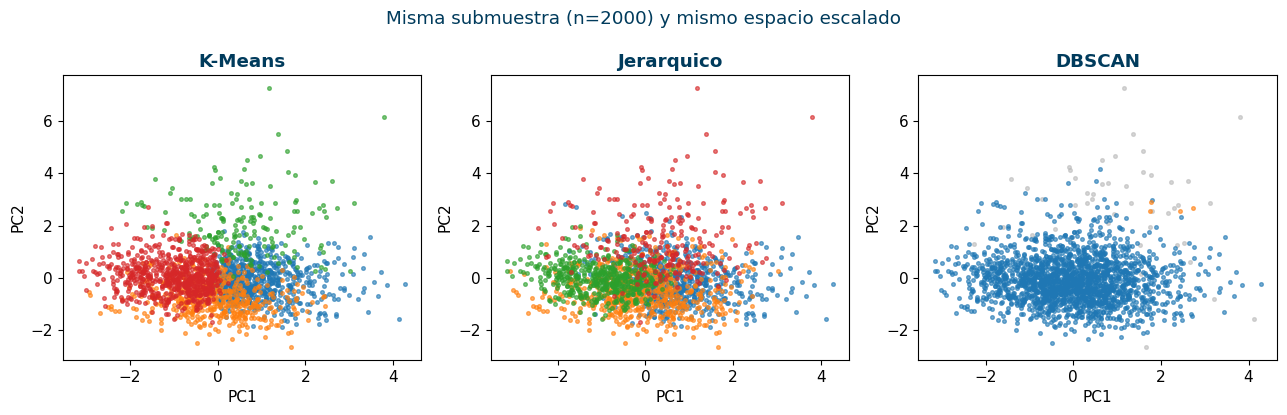

k (K-Means/Ward) = 4  |  DBSCAN eps=1.238 clusters=2 ruido=2.4%
Metricas internas (excluye ruido):
  K-Means      silhouette=0.1758  Calinski-Harabasz=388  Davies-Bouldin=1.5303
  Jerarquico   silhouette=0.1175  Calinski-Harabasz=286  Davies-Bouldin=1.8435
  DBSCAN       silhouette=0.3186  Calinski-Harabasz=13  Davies-Bouldin=0.7196
ARI principal (no-ruido; excluye 2.4% de puntos ruido de DBSCAN):
  KM vs AG = 0.4474 (ambos sin ruido, todos los puntos)
  KM vs DB = 0.0026   AG vs DB = 0.0019
ARI sensibilidad (todos los puntos, -1 como una etiqueta): KM-DB=0.0253  AG-DB=0.0185
Recordatorio: metricas no comparables directamente entre distintos tratamientos del ruido.


In [9]:
def knee_index(y: np.ndarray) -> int:
    """Indice del punto de maxima distancia a la cuerda (determinista).

    Sobre una curva monotona ordenada, devuelve el indice del punto mas alejado de la
    recta que une el primer y el ultimo punto. Es una HEURISTICA del codo: solo sugiere
    un valor candidato, no una curvatura exacta ni una frontera cierta.
    """
    y = np.asarray(y, dtype=float)
    n = len(y)
    x = np.arange(n, dtype=float)
    x1, x2, y1, y2 = x[0], x[-1], y[0], y[-1]
    num = np.abs((y2 - y1) * x - (x2 - x1) * y + x2 * y1 - y2 * x1)
    den = np.hypot(y2 - y1, x2 - x1)
    d = num / (den if den > 0 else 1.0)
    return int(np.argmax(d))


from sklearn.cluster import DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (silhouette_score, calinski_harabasz_score,
                             davies_bouldin_score, adjusted_rand_score)

COMPARE_SUB = 2_000
MIN_SAMPLES = 4

sub_c = df.sample(n=COMPARE_SUB, random_state=SEED)
X_c = StandardScaler().fit_transform(sub_c[CLUSTERING_FEATURES].to_numpy(dtype=float))
X_c_pca = PCA(n_components=2, random_state=SEED).fit_transform(X_c)

# k seleccionada por silhouette en 2..8 (coherente con S04.08)
_Xfull = StandardScaler().fit_transform(df[CLUSTERING_FEATURES].to_numpy(dtype=float))
_sils = []
for k in range(2, 9):
    _l = KMeans(n_clusters=k, n_init=10, random_state=SEED).fit_predict(_Xfull)
    _sils.append(silhouette_score(_Xfull, _l, sample_size=5000, random_state=SEED))
best_k = int(list(range(2, 9))[int(np.argmax(_sils))])

cmp_km = KMeans(n_clusters=best_k, n_init=10, random_state=SEED).fit_predict(X_c)
cmp_ag = AgglomerativeClustering(n_clusters=best_k, linkage="ward").fit_predict(X_c)

nn_c = NearestNeighbors(n_neighbors=MIN_SAMPLES).fit(X_c)   # col 0 = el propio punto (dist 0)
dist_c, _ = nn_c.kneighbors(X_c)
kth_c = np.sort(dist_c[:, -1])
eps_c = float(round(kth_c[knee_index(kth_c)], 3))
cmp_db = DBSCAN(eps=eps_c, min_samples=MIN_SAMPLES).fit_predict(X_c)
cmp_db_nclus = len(set(cmp_db)) - (1 if -1 in cmp_db else 0)
cmp_db_noise = float(np.mean(cmp_db == -1))


def internal_metrics(Xm, labels):
    """Silhouette, Calinski-Harabasz, Davies-Bouldin (excluye ruido -1)."""
    m = labels != -1
    uniq = set(labels[m])
    if len(uniq) < 2 or m.sum() <= len(uniq):
        return (float("nan"), float("nan"), float("nan"))
    Xs, ls = Xm[m], labels[m]
    return (float(silhouette_score(Xs, ls)),
            float(calinski_harabasz_score(Xs, ls)),
            float(davies_bouldin_score(Xs, ls)))

metrics = {"K-Means": internal_metrics(X_c, cmp_km),
           "Jerarquico": internal_metrics(X_c, cmp_ag),
           "DBSCAN": internal_metrics(X_c, cmp_db)}

# ARI: KM vs AG particionan TODOS los puntos (sin ruido).
ari_km_ag = float(adjusted_rand_score(cmp_km, cmp_ag))
# ARI con DBSCAN — PRINCIPAL: solo puntos no-ruido (mismas observaciones), con % excluido.
mask_db = cmp_db != -1
pct_excl = float(1.0 - mask_db.mean())
ari_km_db_main = float(adjusted_rand_score(cmp_km[mask_db], cmp_db[mask_db]))
ari_ag_db_main = float(adjusted_rand_score(cmp_ag[mask_db], cmp_db[mask_db]))
# Sensibilidad: todos los puntos, -1 tratado como una sola etiqueta.
ari_km_db_all = float(adjusted_rand_score(cmp_km, cmp_db))
ari_ag_db_all = float(adjusted_rand_score(cmp_ag, cmp_db))

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
cmap = plt.get_cmap("tab10")
for ax, (name, lab) in zip(axes, [("K-Means", cmp_km), ("Jerarquico", cmp_ag), ("DBSCAN", cmp_db)]):
    for c in sorted(set(lab)):
        mm = lab == c
        col = "#BBBBBB" if c == -1 else cmap(c % 10)
        ax.scatter(X_c_pca[mm, 0], X_c_pca[mm, 1], s=7, alpha=0.6, color=col)
    ax.set_title(name, color=NAVY, fontweight="bold"); ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
fig.suptitle(f"Misma submuestra (n={COMPARE_SUB}) y mismo espacio escalado", color=NAVY)
plt.tight_layout(); plt.show()

print(f"k (K-Means/Ward) = {best_k}  |  DBSCAN eps={eps_c} clusters={cmp_db_nclus} ruido={cmp_db_noise*100:.1f}%")
print("Metricas internas (excluye ruido):")
for name, (sil, ch, dbi) in metrics.items():
    ch_s = f"{ch:,.0f}" if ch == ch else "n/d"
    sil_s = f"{sil:.4f}" if sil == sil else "n/d"
    dbi_s = f"{dbi:.4f}" if dbi == dbi else "n/d"
    print(f"  {name:<12} silhouette={sil_s}  Calinski-Harabasz={ch_s}  Davies-Bouldin={dbi_s}")
print(f"ARI principal (no-ruido; excluye {pct_excl*100:.1f}% de puntos ruido de DBSCAN):")
print(f"  KM vs AG = {ari_km_ag:.4f} (ambos sin ruido, todos los puntos)")
print(f"  KM vs DB = {ari_km_db_main:.4f}   AG vs DB = {ari_ag_db_main:.4f}")
print(f"ARI sensibilidad (todos los puntos, -1 como una etiqueta): "
      f"KM-DB={ari_km_db_all:.4f}  AG-DB={ari_ag_db_all:.4f}")
print("Recordatorio: metricas no comparables directamente entre distintos tratamientos del ruido.")


## 8. Interpretación actuarial y limitaciones

**Uso actuarial (prudente):**
- Análisis de la **estructura anidada** de perfiles de la cartera a distintos niveles.
- Clasificación jerárquica exploratoria de perfiles de emisión.

**Limitaciones:**
- Complejidad O(n²) → obliga a submuestrear; la submuestra introduce variabilidad muestral.
- Ward usa distancia euclidiana (requiere escalar) y es sensible a outliers.
- El corte del dendrograma es una decisión; distintos cortes dan distintas particiones.
- Las métricas internas no son comparables entre espacios/muestras/tratamientos del ruido.
- Ningún método es universalmente superior: la elección es condicional al problema.

## 9. Ejercicio propuesto

1. **Otro linkage:** repite con `method="complete"` y `method="average"`. ¿Cambia el dendrograma?
   ¿Y el ARI con K-Means (sobre la misma submuestra)?
2. **Otro corte:** corta en K = 3 y K = 5. Interpreta los grupos resultantes.
3. **Análisis de sensibilidad:** sobre la **misma** submuestra, cambia el escalador o el linkage y
   mide el ARI contra la partición Ward (mismas observaciones); interpreta un ARI bajo como
   evidencia de que la partición es **sensible** a esa decisión (no como (in)estabilidad del
   algoritmo). Para **otra** submuestra, compara los **perfiles descriptivos** de los grupos, no
   ARI (observaciones diferentes).

---

### Referencias bibliográficas

- Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical Learning* (2nd ed.). Cap. 14 §14.3.12.
- James, G., et al. (2023). *An Introduction to Statistical Learning with Applications in Python*. Cap. 12 §12.4.2.
- scikit-learn Developers. *User Guide* v1.9.0. `AgglomerativeClustering`, `KMeans`, `DBSCAN`, métricas de clustering.
- scipy.cluster.hierarchy: `linkage`, `dendrogram`, `fcluster`.
- Wüthrich, M. V., & Buser, C. *Data Analytics for Non-Life Insurance Pricing*. Swiss Finance Institute Research Paper No. 16-68. SSRN: https://ssrn.com/abstract=2870308 (consultado 2026-06-17). Cap. 2 (contexto general de ML en seguros de no-vida).